<a href="https://colab.research.google.com/github/maxwellugwu808-ui/FFNetwork/blob/main/classification_model_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [175]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [176]:
breast_cancer_data = load_breast_cancer()
X = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)
Y = pd.DataFrame(breast_cancer_data.target, columns=['target'])

In [177]:
c = pd.concat([X,Y], axis=1)

In [178]:
d = 0
for i,row in c.iterrows():
  if row['target']==1 and d <141 :
    c.drop(i, inplace=True)
    d+=1

In [179]:
a = np.unique(c['target'], return_counts=True)
print(a)

(array([0, 1]), array([212, 216]))


In [180]:
X1 = c.drop('target', axis=1)
Y1 = c['target']

In [181]:
x_train, x_test, y_train, y_test = train_test_split(X1, Y1, test_size=0.2, stratify=Y1,random_state=25,shuffle=True)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [182]:
a = np.unique(y_train, return_counts=True)
print(a)

(array([0, 1]), array([169, 173]))


In [183]:
x_train = torch.tensor(x_train).float()
x_test = torch.tensor(x_test).float()
y_train = torch.tensor(np.array(y_train)).long()
y_test = torch.tensor(np.array(y_test)).long()

In [184]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

(torch.Size([342, 30]),
 torch.Size([342]),
 torch.Size([86, 30]),
 torch.Size([86]))

In [185]:
tensor_train = TensorDataset(x_train, y_train)
tensor_test = TensorDataset(x_test, y_test)

In [186]:
class DiabetesFNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1 = nn.Linear(30,68)
    self.l2 = nn.Linear(68, 28)
    self.l3 = nn.Linear(28,1)
  def forward(self, x):
    x = F.relu(self.l1(x))
    x = F.relu(self.l2(x))
    x = torch.sigmoid(self.l3(x)) # Corrected from Sigmoid to torch.sigmoid
    return x

In [187]:
diaclass = DiabetesFNN()
loss = nn.BCELoss()
optimizer = torch.optim.SGD(diaclass.parameters(),lr=0.1)

In [188]:
numepochs = 200

lossvalues=torch.zeros(numepochs)

training_acc = []
testing_acc = []
for epochs in range(numepochs):
    diaclass.train()
    yhat = diaclass.forward(tensor_train.tensors[0])
    # Reshape the target tensor to match the output of the model and convert to float
    target_labels = tensor_train.tensors[1].unsqueeze(1).float()
    loss1 = loss(yhat, target_labels)
    lossvalues[epochs] = loss1

    optimizer.zero_grad()
    # For BCELoss, the backward pass should be called on the loss scalar
    loss1.backward()
    optimizer.step()

    # Convert yhat to predictions (0 or 1) for accuracy calculation
    predictions = (yhat > 0.5).float()
    matchd = (predictions == target_labels)
    acc = (matchd.sum().item() / len(matchd)) * 100
    training_acc.append(acc)

    diaclass.eval()
    test_predictions = (diaclass.forward(tensor_test.tensors[0]) > 0.5).float()
    test_matchd = (test_predictions == tensor_test.tensors[1].unsqueeze(1).float())
    test_acc = (test_matchd.sum().item() / len(test_matchd)) * 100
    testing_acc.append(test_acc)

# Calculate total accuracy after the loop
final_yhat = diaclass.forward(tensor_train.tensors[0])
final_target_labels = tensor_train.tensors[1].unsqueeze(1).float()
final_predictions = (final_yhat > 0.5).float()
m = (final_predictions == final_target_labels)
total_acc = (m.sum().item() / len(m)) * 100
total_acc

98.83040935672514

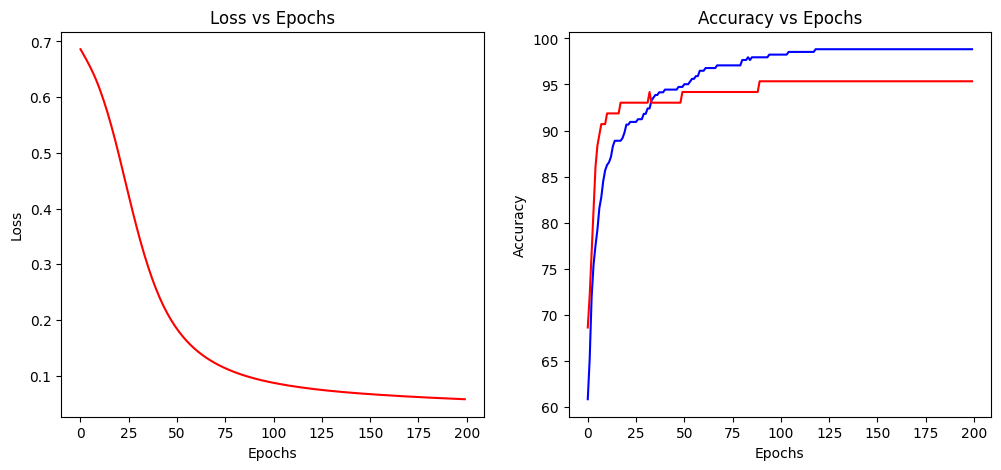

In [189]:
fig , ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(lossvalues.detach(),'r')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss vs Epochs')

ax[1].plot(training_acc, 'b')
ax[1].plot(testing_acc, 'r')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy vs Epochs')
plt.show()